# 1. El Miércoles Negro: Anatomía de una Crisis Cambiaria

---

## Objetivo de este Notebook

Antes de desarrollar cualquier algoritmo predictivo, necesitamos **comprender profundamente el fenómeno** que queremos detectar. En este notebook analizaremos:

1. **¿Qué fue el Mecanismo Europeo de Cambio (MEC)?** - El sistema que colapsó
2. **¿Qué ocurrió el 16 de septiembre de 1992?** - El "Miércoles Negro"
3. **¿Qué señales económicas precedieron al colapso?** - La evidencia en los datos

Al final de este análisis, tendremos la intuición necesaria para diseñar un sistema de detección temprana.

---

## 1.1. El Mecanismo Europeo de Cambio (MEC)

Antes de la creación del Euro, la mayoría de los países de la Comunidad Económica Europea (CEE) formaban parte del **Mecanismo Europeo de Cambio (MEC)**, fundado en 1979.

### ¿Qué era el MEC y para qué servía?

El objetivo principal del MEC era **reducir la volatilidad** entre las monedas europeas y **fomentar la estabilidad** económica. Se consideraba un paso fundamental para crear un mercado único y, eventualmente, una moneda única (el Euro).

Funcionaba así:

1. **Ancla del Sistema:** El **Marco Alemán (DEM)** era el "ancla" no oficial del sistema. Debido a la fortaleza y baja inflación de la economía alemana, las demás monedas buscaban mantener un valor estable frente al DEM.

2. **Bandas de Fluctuación:** Cada moneda tenía un tipo de cambio central fijado frente a las demás. Solo se les permitía fluctuar dentro de una "banda" estrecha (generalmente ±2.25% o ±6%) alrededor de ese tipo central.

3. **Intervención Obligatoria:** Si una moneda se debilitaba y se acercaba al límite inferior de su banda, su banco central estaba **obligado a intervenir**: debía **comprar** su propia moneda (gastando sus reservas de divisas, como el DEM) para subirle el precio.

### El Problema: Tensiones Insostenibles

Este sistema se volvió insostenible a principios de los 90. Tras la **reunificación alemana** (1990), Alemania subió sus tipos de interés para controlar la inflación. Esto hizo al DEM *aún más fuerte* y atrajo capital, debilitando a las demás monedas.

Países como el **Reino Unido (GBP)** e **Italia (ITL)** sufrían una recesión y **no podían permitirse subir sus tipos de interés** para igualar a Alemania (eso habría hundido más sus economías).

Los especuladores (como **George Soros**) vieron esta debilidad y apostaron miles de millones a que el Reino Unido e Italia no podrían seguir gastando sus reservas para defender un tipo de cambio artificialmente alto.

Tenían razón.

## 1.2. Configuración del Entorno

Importamos las librerías necesarias para el análisis.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

# Fecha clave
BLACK_WEDNESDAY = pd.to_datetime('1992-09-16')

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


---

## 1.3. Análisis del Tipo de Cambio GBP/DEM

Comenzamos estudiando la evolución del tipo de cambio entre la Libra Esterlina y el Marco Alemán. Este es el indicador más visible de la crisis.

In [9]:
# Cargar datos de tipo de cambio
df_exchange = pd.read_excel('../data/ExchangeRateData.xlsx')

print(f"Datos cargados: {len(df_exchange)} registros")
print(f"Período: {df_exchange['Date'].min()} a {df_exchange['Date'].max()}")
df_exchange.head()

Datos cargados: 1042 registros
Período: 1991-01-02 00:00:00 a 1994-12-30 00:00:00


,Date,Exchange Rate
0,1994-12-30,2.425734
1,1994-12-29,2.420967
2,1994-12-28,2.423308
3,1994-12-27,2.433853
4,1994-12-26,2.435626


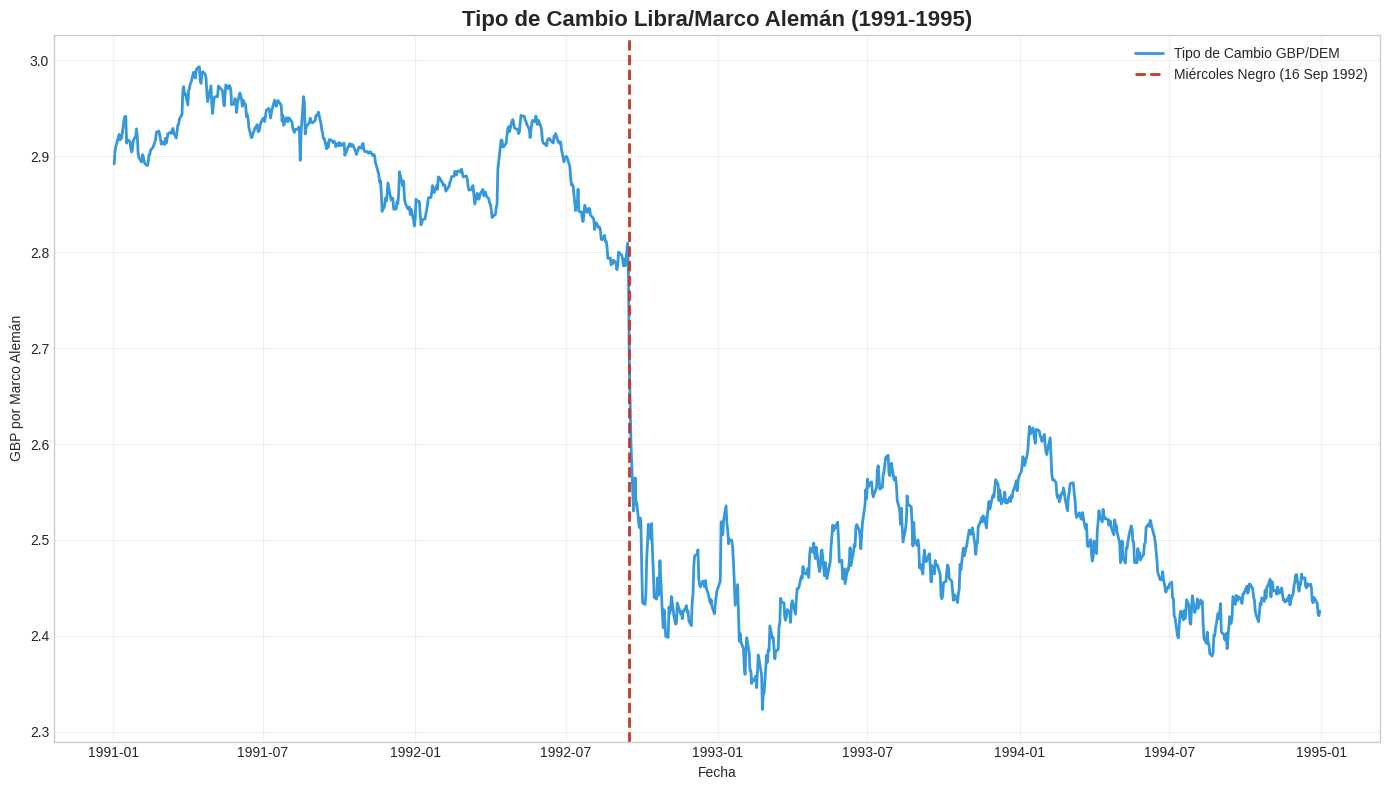

In [10]:
plt.figure(figsize=(14, 8))
plt.plot(df_exchange['Date'], df_exchange['Exchange Rate'], 
         label='Tipo de Cambio GBP/DEM', color='#3498db', linewidth=2)

# Marcar el Miércoles Negro
plt.axvline(x=BLACK_WEDNESDAY, color='#c0392b', linestyle='--', linewidth=2, 
            label='Miércoles Negro (16 Sep 1992)')

plt.title('Tipo de Cambio Libra/Marco Alemán (1991-1995)', fontsize=16, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('GBP por Marco Alemán')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del Gráfico

Podemos dividir el gráfico en **tres fases claras**:

#### Fase 1: Estabilidad Aparente (Ene 1991 - Sep 1992)
- **Valor alto y estable:** La libra se mantiene fuerte, fluctuando entre 2.9 y 3.0 marcos alemanes
- **Contexto:** El MEC mantenía las monedas "atadas" artificialmente

#### Fase 2: El Colapso (Septiembre 1992)
- **Caída vertical:** En días, la libra cae de ~2.8 a ~2.3 marcos
- **Significado:** Devaluación masiva del ~20%
- **Causa:** El gobierno británico agotó sus reservas intentando defender la libra y tuvo que rendirse

#### Fase 3: Nueva Normalidad (Post-1992)
- **Nivel permanentemente más bajo:** La libra nunca recupera su valor anterior
- **Alta volatilidad:** Sin el ancla del MEC, fluctúa libremente

---

## 1.4. Análisis de las Reservas Internacionales

El tipo de cambio es el **síntoma visible**. Pero las **reservas internacionales** nos muestran lo que ocurría **detrás del escenario**: la intervención desesperada de los bancos centrales.

In [11]:
# Cargar datos de reservas
df_reserves = pd.read_excel('../data/ReservesData.xlsx')

print(f"Datos cargados: {len(df_reserves)} registros")
df_reserves.head()

Datos cargados: 48 registros


,Date,Total Reserves
0,1994-12-31,4.632667e+10
1,1994-11-30,4.615525e+10
2,1994-10-31,4.721191e+10
3,1994-09-30,4.596999e+10
4,1994-08-31,4.548646e+10


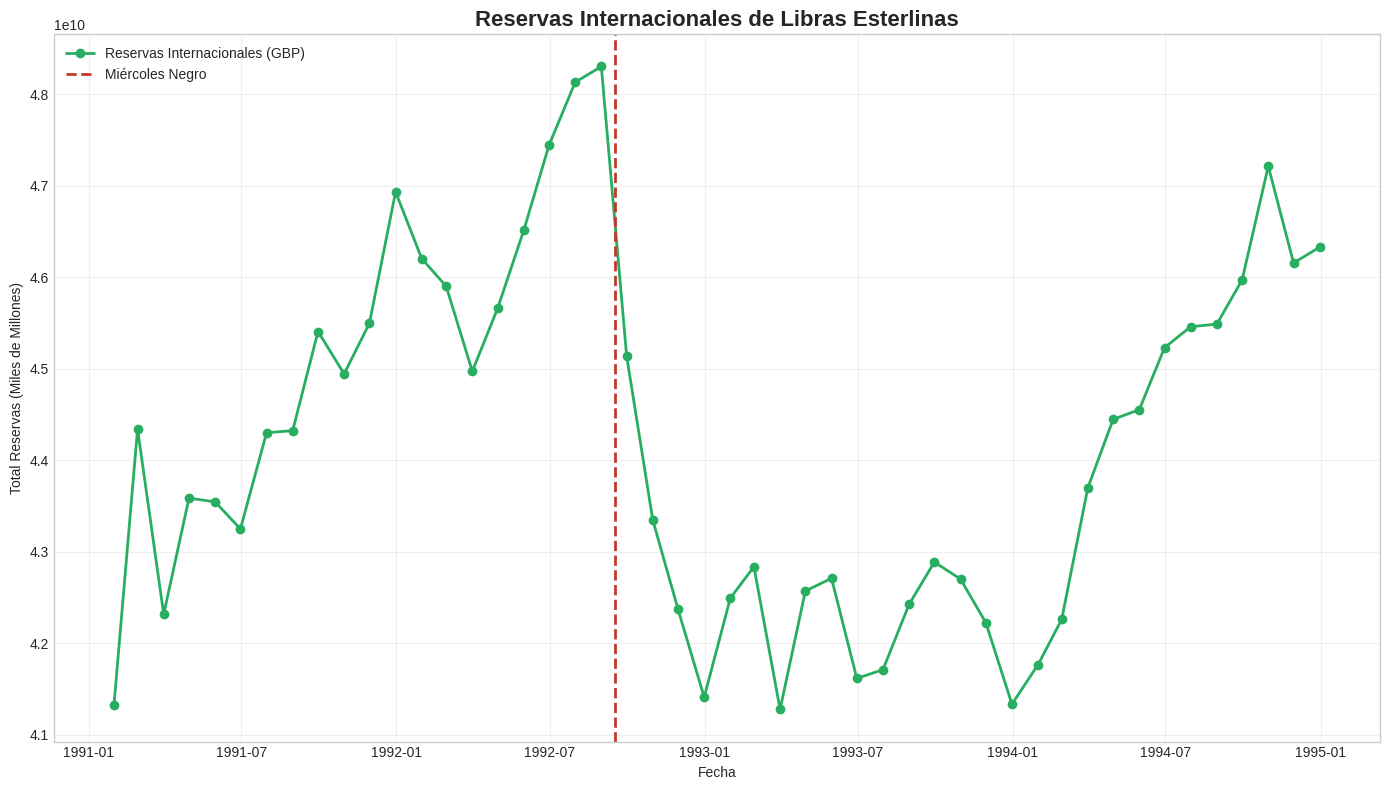

In [12]:
plt.figure(figsize=(14, 8))
plt.plot(df_reserves['Date'], df_reserves['Total Reserves'], 
         label='Reservas Internacionales (GBP)', color='#27ae60', linewidth=2, marker='o')

plt.axvline(x=BLACK_WEDNESDAY, color='#c0392b', linestyle='--', linewidth=2,
            label='Miércoles Negro')

plt.title('Reservas Internacionales de Libras Esterlinas', fontsize=16, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Total Reservas (Miles de Millones)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación: La Anatomía de una Intervención Fallida

Este gráfico es **la prueba de la intervención coordinada y fallida** de los bancos centrales europeos.

#### El Pico: La Defensa Desesperada (Mediados de 1992)
- **Qué vemos:** Aumento masivo de reservas hasta ~48 mil millones justo antes del 16 de septiembre
- **Significado:** Los bancos centrales (principalmente el Bundesbank) estaban **comprando libras forzosamente** para evitar que el precio cayera
- **La trampa:** Cada libra comprada se convertía en un activo tóxico si la libra se devaluaba

#### El Desplome: El Pánico (Post-16 de Septiembre)
- **Qué vemos:** Caída abrupta de 48 a 41 mil millones
- **Significado:** Una vez que UK abandonó el MEC, todos los bancos centrales que habían acumulado libras empezaron a **venderlas masivamente** para limitar pérdidas

> **Insight clave:** Las reservas nos dan una señal **adelantada**. El pico de reservas indica pánico institucional ANTES de que el precio colapse.

---

## 1.5. La Gran Divergencia: Comparación entre Monedas

Para entender la magnitud del colapso, comparamos la evolución de las principales monedas del MEC. 

**Problema técnico:** Las escalas son muy diferentes (1 lira ≈ 1200, 1 libra ≈ 1.6).

**Solución:** Normalizamos los datos fijando todas las monedas en **100** el 1 de enero de 1990. Así vemos el **crecimiento/caída porcentual** desde ese punto.

In [13]:
# Cargar y limpiar datos de múltiples monedas
df = pd.read_excel('../data/tipoDeCambioEuropa.xlsx', skiprows=3)

# Limpiar estructura
df_cleaned = df.iloc[3:].copy()
df_cleaned.columns = ['Basura', 'Date', 'DEM', 'ITL', 'ESP', 'GBP']
df_cleaned = df_cleaned.drop(columns=['Basura'])
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

# Convertir a numérico
for col in ['DEM', 'ITL', 'ESP', 'GBP']:
    df_cleaned[col] = df_cleaned[col].astype(str).str.replace(',', '.')
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

df_cleaned = df_cleaned.dropna().set_index('Date').sort_index()

print(f"Datos limpios: {len(df_cleaned)} registros")
print(f"Período: {df_cleaned.index.min()} a {df_cleaned.index.max()}")

Datos limpios: 9022 registros
Período: 1990-01-01 00:00:00 a 2024-07-30 00:00:00


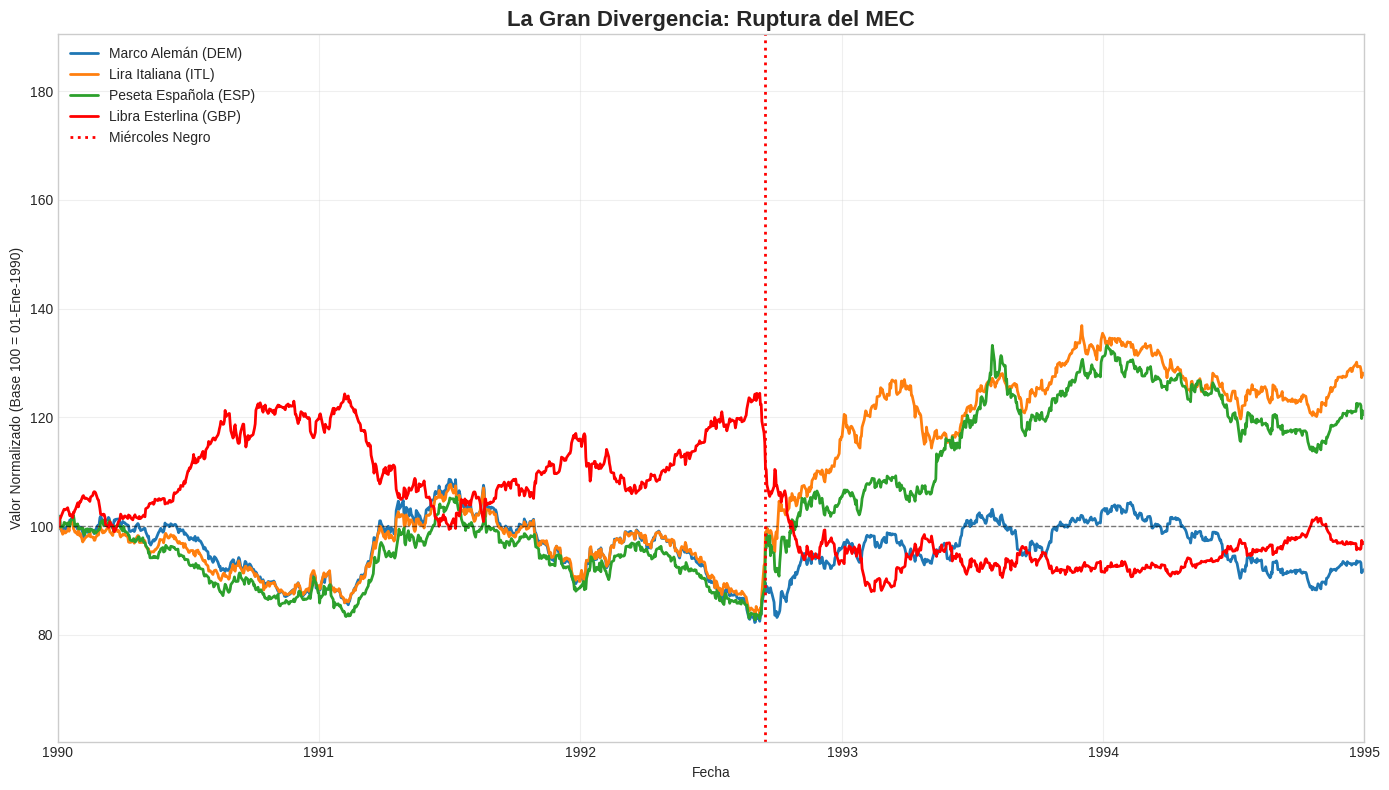

In [14]:
# Normalizar (Base 100 = 1 Ene 1990)
df_normalized = df_cleaned.div(df_cleaned.iloc[0]) * 100

# Gráfico
plt.figure(figsize=(14, 8))

plt.plot(df_normalized['DEM'], label='Marco Alemán (DEM)', linewidth=2)
plt.plot(df_normalized['ITL'], label='Lira Italiana (ITL)', linewidth=2)
plt.plot(df_normalized['ESP'], label='Peseta Española (ESP)', linewidth=2)
plt.plot(df_normalized['GBP'], label='Libra Esterlina (GBP)', linewidth=2, color='red')

plt.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(BLACK_WEDNESDAY, color='red', linestyle=':', linewidth=2, label='Miércoles Negro')

plt.title('La Gran Divergencia: Ruptura del MEC', fontsize=16, weight='bold')
plt.ylabel('Valor Normalizado (Base 100 = 01-Ene-1990)')
plt.xlabel('Fecha')
plt.xlim(pd.to_datetime('1990-01-01'), pd.to_datetime('1995-01-01'))
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### Interpretación: Las Tres Fases de la Ruptura

#### Fase 1: La "Burbuja" de la Libra (Principios de 1991)
- La GBP se dispara hacia arriba (se fortalece)
- **Causa:** UK acababa de entrar al MEC con tipos de interés del ~15%
- Los inversores compraron libras masivamente por el alto rendimiento
- **Esto era artificial e insostenible**

#### Fase 2: Corrección y Tensión (Mediados 1991 - 1992)
- La GBP empieza a caer desde su pico artificial
- La economía británica entra en recesión (los tipos del 15% la asfixiaban)
- Alemania mantiene tipos altos → el DEM se fortalece
- **Contradicción fatal:** UK necesitaba tipos bajos pero el MEC le obligaba a mantenerlos altos

#### Fase 3: El Colapso (Septiembre 1992)
- Los especuladores apostaron a que UK no aguantaría
- La GBP y la ITL se desploman
- **El sistema se rompe**

---

## 1.6. Conclusiones: ¿Qué Señales Precedieron al Colapso?

Nuestro análisis revela que la crisis del Miércoles Negro **no fue un evento sorpresa**. Hubo señales claras en los datos:

### Señales de Peligro Identificadas

| Señal | Comportamiento Pre-Crisis | Interpretación |
|-------|---------------------------|----------------|
| **Reservas** | Pico anormal → Caída abrupta | Intervención desesperada del banco central |
| **Tipo de Cambio** | Estabilidad artificial → Volatilidad | El precio estaba "sostenido" artificialmente |
| **Divergencia** | Separación entre monedas | El sistema de bandas se estaba rompiendo |

### La Pregunta Clave

> **¿Podríamos haber detectado estas señales automáticamente ANTES del colapso?**

Esta es precisamente la pregunta que abordaremos en el siguiente notebook, donde desarrollaremos un algoritmo basado en la **Teoría del Peligro (Danger Theory)** de la inmunología computacional.

La idea central es que, al igual que el sistema inmune detecta "señales de peligro" internas antes de que una enfermedad se manifieste externamente, podemos entrenar un sistema para detectar el "estrés financiero" antes de que el precio colapse.

---

**→ Continúa en: `02_desarrollo_algoritmo.ipynb`**